# CIFAR-10 Image Classification using ANN and CNN

## Assignment Objective
Build an image classification model on the CIFAR-10 dataset and analyze performance across different architectures and training strategies.

In this notebook, I trained and compared:

1. **ANN (Artificial Neural Network)**
2. **Basic CNN (Convolutional Neural Network)**
3. **Improved CNN with Batch Normalization and Dropout**
4. **CNN with Data Augmentation and Early Stopping**

The final analysis compares accuracy, loss, confusion matrix, classification report, and model behavior.

## 1. Import Required Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.20.0


## 2. Load CIFAR-10 Dataset

CIFAR-10 contains **60,000 color images** of size **32 × 32 × 3**.

- 50,000 training images
- 10,000 test images
- 10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)

Training data shape: (50000, 32, 32, 3)
Testing data shape: (10000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing labels shape: (10000, 1)


## 3. Visualize Sample Images

/tmp/ipykernel_2700/2488826609.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y_train[i])])


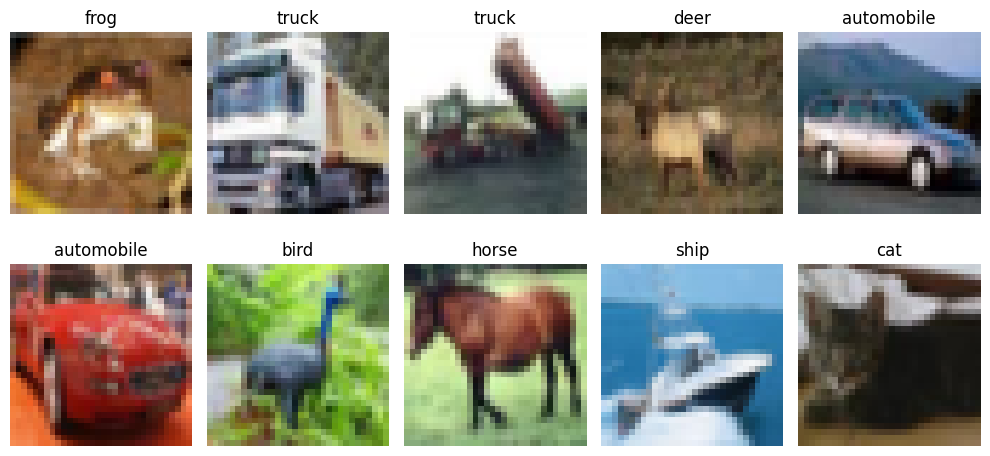

In [ ]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[int(y_train[i])])
    plt.axis('off')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

Pixel values are originally in the range **0 to 255**.  
We normalize them to **0 to 1** so the model trains faster and more smoothly.

For ANN, images are flattened into vectors.  
For CNN, original image shape is preserved.

In [ ]:
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

# ANN needs flat input: 32*32*3 = 3072 features
x_train_flat = x_train_norm.reshape(x_train_norm.shape[0], -1)
x_test_flat = x_test_norm.reshape(x_test_norm.shape[0], -1)

print("ANN train shape:", x_train_flat.shape)
print("CNN train shape:", x_train_norm.shape)

ANN train shape: (50000, 3072)
CNN train shape: (50000, 32, 32, 3)


## 5. Helper Functions

These functions are used for plotting learning curves and evaluating models.

In [ ]:
def plot_history(history, title):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(title + ' - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(title + ' - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()


def evaluate_model(model, x_test_data, y_test_data, model_name):
    test_loss, test_accuracy = model.evaluate(x_test_data, y_test_data, verbose=0)
    print(f"{model_name} Test Loss: {test_loss:.4f}")
    print(f"{model_name} Test Accuracy: {test_accuracy:.4f}")
    return test_loss, test_accuracy

## 6. Model 1: ANN Architecture

ANN treats each image as a flat vector of 3072 values.  
It can classify images, but it does not understand spatial relationships like edges, shapes, and textures.

In [ ]:
ann_model = models.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.2430 - loss: 2.0498 - val_accuracy: 0.3268 - val_loss: 1.8671
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.2950 - loss: 1.9083 - val_accuracy: 0.3548 - val_loss: 1.8157
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.3150 - loss: 1.8635 - val_accuracy: 0.3660 - val_loss: 1.7945
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3200 - loss: 1.8409 - val_accuracy: 0.3784 - val_loss: 1.7706
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3316 - loss: 1.8238 - val_accuracy: 0.3754 - val_loss: 1.7758
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3393 - loss: 1.8111 - val_accuracy: 0.3766 - val_loss: 1.7680
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 27ms/step - accuracy: 0.3438 - loss: 1.7959 - val_accuracy: 0.3770 - val_loss: 1.7499
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3521 - loss: 1.7815 - 

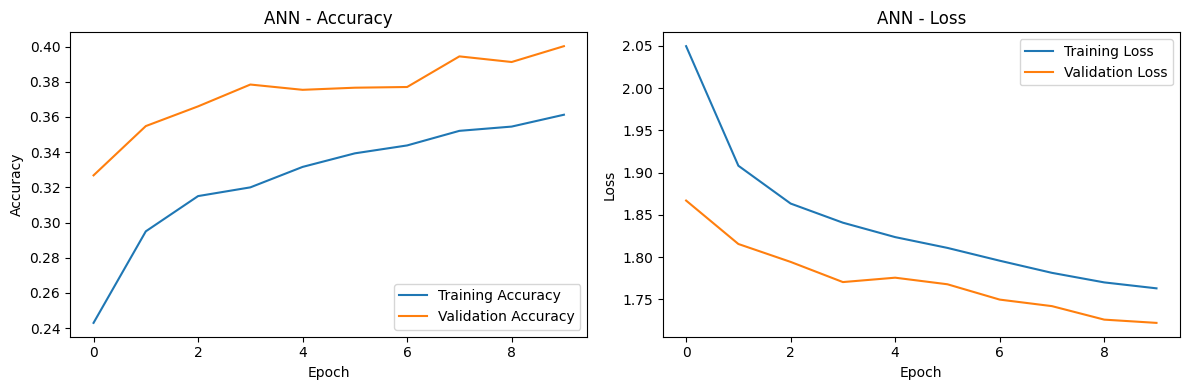

In [ ]:
ann_history = ann_model.fit(
    x_train_flat,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

ann_loss, ann_acc = evaluate_model(ann_model, x_test_flat, y_test, "ANN")
plot_history(ann_history, "ANN")

## 7. Model 2: Basic CNN Architecture

CNN is better for images because it keeps the 2D structure of images and learns local patterns using convolution filters.

In [ ]:
basic_cnn_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

basic_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

basic_cnn_model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 74ms/step - accuracy: 0.4581 - loss: 1.5050 - val_accuracy: 0.5716 - val_loss: 1.2214
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 72ms/step - accuracy: 0.5912 - loss: 1.1621 - val_accuracy: 0.6162 - val_loss: 1.0898
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 51s 73ms/step - accuracy: 0.6389 - loss: 1.0294 - val_accuracy: 0.6632 - val_loss: 0.9789
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 74ms/step - accuracy: 0.6758 - loss: 0.9266 - val_accuracy: 0.6680 - val_loss: 0.9667
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 72ms/step - accuracy: 0.7058 - loss: 0.8525 - val_accuracy: 0.6934 - val_loss: 0.8910
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 73ms/step - accuracy: 0.7291 - loss: 0.7808 - val_accuracy: 0.6730 - val_loss: 0.9719
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 74ms/step - accuracy: 0.7497 - loss: 0.7215 - val_accuracy: 0.7028 - val_loss: 0.8776
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 74ms/step - accuracy: 0.7697 - loss: 0.6663 - 

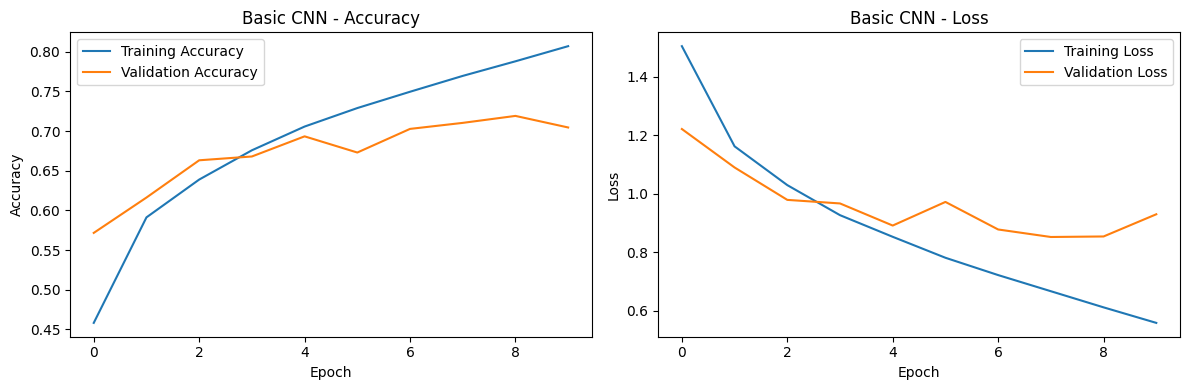

In [ ]:
basic_cnn_history = basic_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

basic_cnn_loss, basic_cnn_acc = evaluate_model(basic_cnn_model, x_test_norm, y_test, "Basic CNN")
plot_history(basic_cnn_history, "Basic CNN")

## 8. Model 3: Improved CNN with Batch Normalization and Dropout

Training strategies used:

- **Batch Normalization:** stabilizes and speeds up training
- **Dropout:** reduces overfitting
- **More convolution layers:** improves feature extraction

In [ ]:
improved_cnn_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.30),

    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.40),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.50),
    layers.Dense(10, activation='softmax')
])

improved_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

improved_cnn_model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 668,842 (2.55 MB)

 Trainable params: 667,690 (2.55 MB)

 Non-trainable params: 1,152 (4.50 KB)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 304s 424ms/step - accuracy: 0.4391 - loss: 1.6724 - val_accuracy: 0.5742 - val_loss: 1.1927
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 295s 420ms/step - accuracy: 0.6048 - loss: 1.1074 - val_accuracy: 0.6652 - val_loss: 0.9604
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 329s 430ms/step - accuracy: 0.6615 - loss: 0.9542 - val_accuracy: 0.7258 - val_loss: 0.8005
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 300s 427ms/step - accuracy: 0.6956 - loss: 0.8677 - val_accuracy: 0.7468 - val_loss: 0.7424
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 300s 427ms/step - accuracy: 0.7194 - loss: 0.7979 - val_accuracy: 0.7344 - val_loss: 0.7501
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 301s 427ms/step - accuracy: 0.7372 - loss: 0.7526 - val_accuracy: 0.7526 - val_loss: 0.7059
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 319s 423ms/step - accuracy: 0.7515 - loss: 0.7099 - val_accuracy: 0.7856 - val_loss: 0.6368
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 325s 427ms/step - accuracy: 0.7639 -

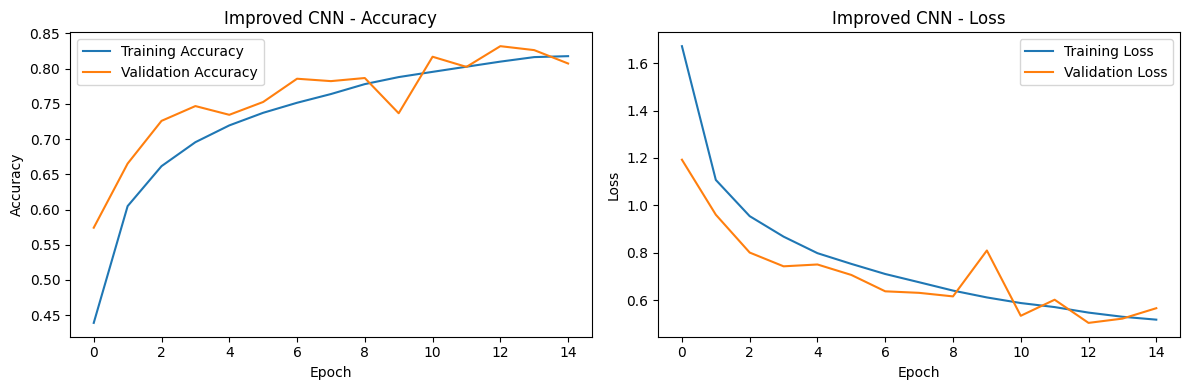

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

improved_cnn_history = improved_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

improved_cnn_loss, improved_cnn_acc = evaluate_model(improved_cnn_model, x_test_norm, y_test, "Improved CNN")
plot_history(improved_cnn_history, "Improved CNN")

## 9. Model 4: CNN with Data Augmentation

Data augmentation creates slightly modified images during training.  
This improves generalization because the model sees different versions of the same image.

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

aug_cnn_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,

    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_cnn_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_8 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621,258 (2.37 MB)

 Trainable params: 620,810 (2.37 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 146s 202ms/step - accuracy: 0.3790 - loss: 1.7499 - val_accuracy: 0.5002 - val_loss: 1.3996
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 203ms/step - accuracy: 0.4739 - loss: 1.4657 - val_accuracy: 0.4980 - val_loss: 1.4845
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 199ms/step - accuracy: 0.5271 - loss: 1.3293 - val_accuracy: 0.6036 - val_loss: 1.1245
Augmented CNN Test Loss: 1.4085
Augmented CNN Test Accuracy: 0.4949


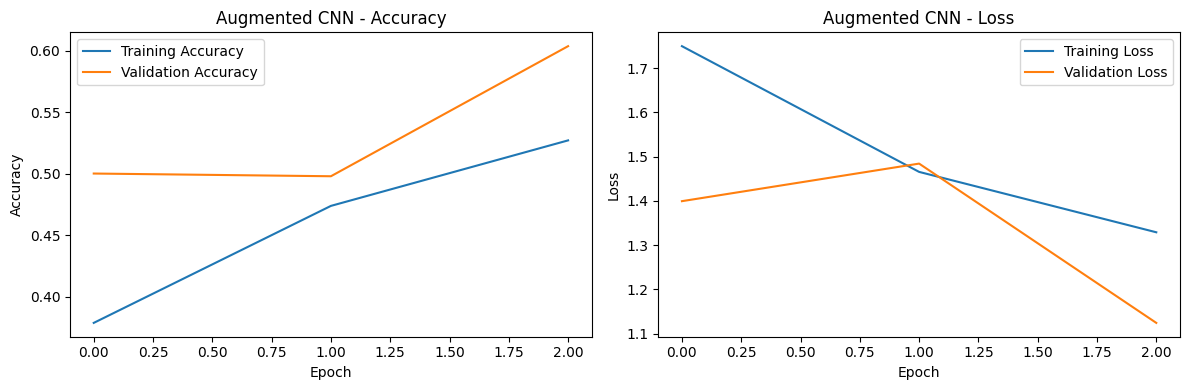

In [ ]:
aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

aug_cnn_loss, aug_cnn_acc = evaluate_model(aug_cnn_model, x_test_norm, y_test, "Augmented CNN")
plot_history(aug_history, "Augmented CNN")

## 10. Model Performance Comparison

In [ ]:
comparison_df = pd.DataFrame({
    'Model': ['ANN', 'Basic CNN', 'Improved CNN', 'Augmented CNN'],
    'Test Loss': [ann_loss, basic_cnn_loss, improved_cnn_loss, aug_cnn_loss],
    'Test Accuracy': [ann_acc, basic_cnn_acc, improved_cnn_acc, aug_cnn_acc]
})

comparison_df

,Model,Test Loss,Test Accuracy
0,ANN,1.703274,0.4105
1,Basic CNN,0.928082,0.7041
2,Improved CNN,0.526971,0.8140
3,Augmented CNN,1.408527,0.4949


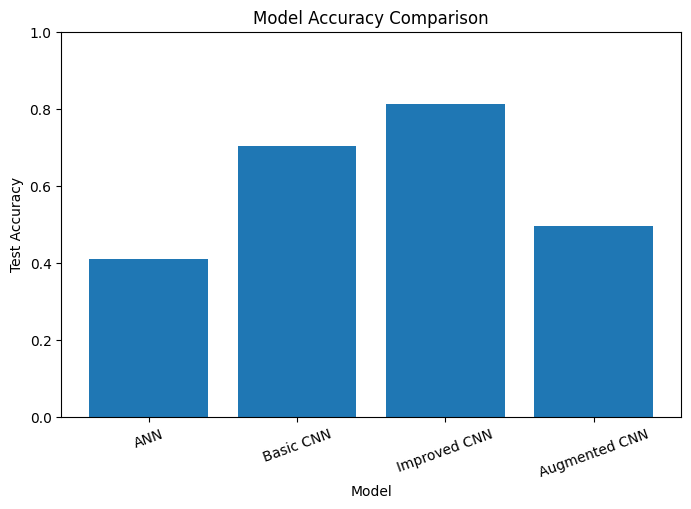

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(comparison_df['Model'], comparison_df['Test Accuracy'])
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

## 11. Confusion Matrix and Classification Report

The best model is selected using test accuracy, then we analyze its class-wise performance.

In [ ]:
models_dict = {
    'ANN': (ann_model, x_test_flat),
    'Basic CNN': (basic_cnn_model, x_test_norm),
    'Improved CNN': (improved_cnn_model, x_test_norm),
    'Augmented CNN': (aug_cnn_model, x_test_norm)
}

best_model_name = comparison_df.sort_values('Test Accuracy', ascending=False).iloc[0]['Model']
best_model, best_x_test = models_dict[best_model_name]

print("Best Model:", best_model_name)

y_pred_prob = best_model.predict(best_x_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = y_test.flatten()

print(classification_report(y_true, y_pred, target_names=class_names))

Best Model: Improved CNN
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 49ms/step
              precision    recall  f1-score   support

    airplane       0.82      0.84      0.83      1000
  automobile       0.93      0.91      0.92      1000
        bird       0.80      0.66      0.72      1000
         cat       0.69      0.62      0.65      1000
        deer       0.81      0.79      0.80      1000
         dog       0.68      0.79      0.73      1000
        frog       0.75      0.92      0.83      1000
       horse       0.92      0.81      0.86      1000
        ship       0.91      0.89      0.90      1000
       truck       0.87      0.91      0.89      1000

    accuracy                           0.81     10000
   macro avg       0.82      0.81      0.81     10000
weighted avg       0.82      0.81      0.81     10000



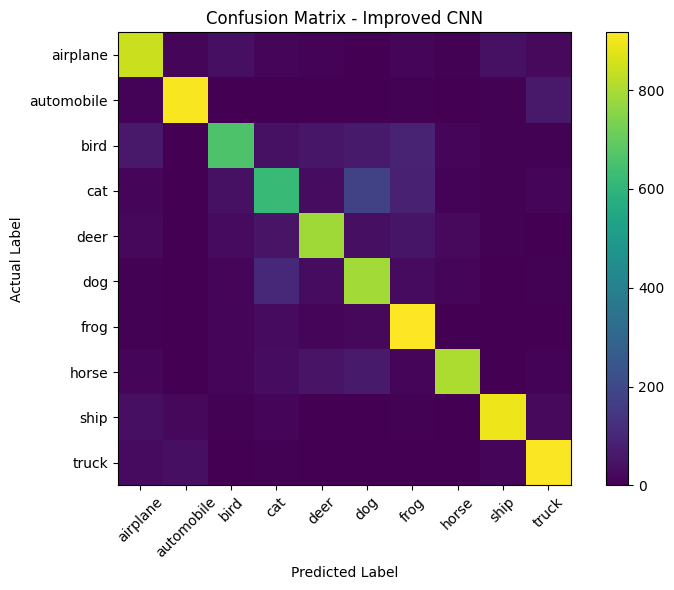

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title('Confusion Matrix - ' + best_model_name)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.xticks(range(10), class_names, rotation=45)
plt.yticks(range(10), class_names)
plt.colorbar()
plt.tight_layout()
plt.show()

## 12. Prediction on Sample Test Images

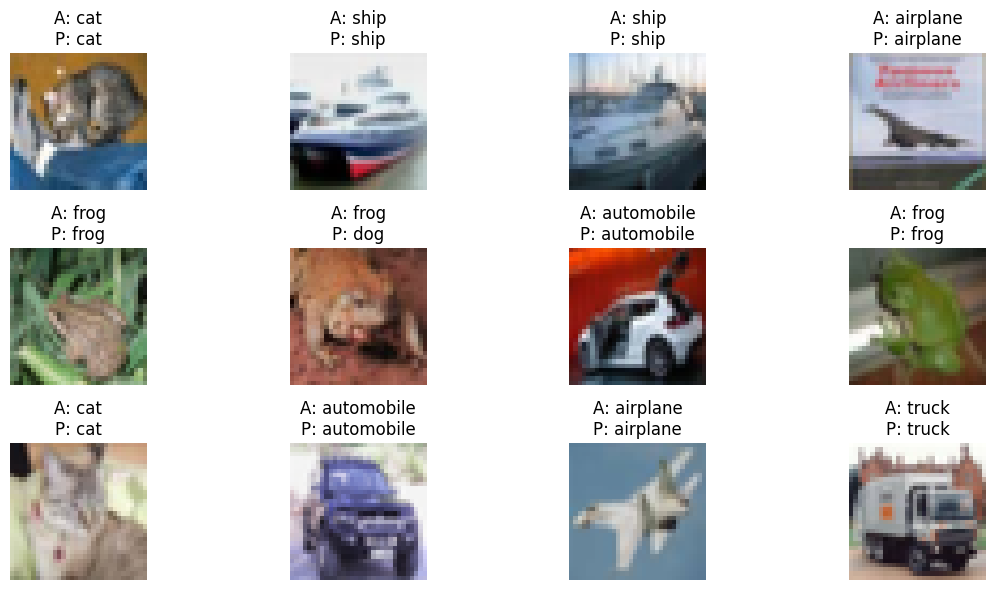

In [ ]:
plt.figure(figsize=(12, 6))
for i in range(12):
    image = x_test_norm[i]

    if best_model_name == 'ANN':
        pred = best_model.predict(image.reshape(1, -1), verbose=0)
    else:
        pred = best_model.predict(image.reshape(1, 32, 32, 3), verbose=0)

    predicted_class = class_names[np.argmax(pred)]
    actual_class = class_names[int(y_test[i][0])]

    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[i])
    plt.title(f"A: {actual_class}\nP: {predicted_class}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## 13. Final Analysis

### ANN vs CNN
ANN uses flattened image pixels, so it loses spatial information. Because of this, ANN usually gives lower accuracy on image datasets.

CNN performs better because it uses convolution layers to detect edges, textures, shapes, and object patterns from images.

### Effect of Training Strategies
- **Dropout** helps reduce overfitting.
- **Batch Normalization** helps stabilize and speed up training.
- **Data Augmentation** improves generalization by creating modified versions of training images.
- **Early Stopping** prevents unnecessary training when validation performance stops improving.

### Overall Observation
The CNN-based models perform better than ANN because CIFAR-10 is an image dataset and CNN is designed for image feature extraction.

## 14. Conclusion

In this assignment, I built image classification models on the CIFAR-10 dataset using both ANN and CNN. The ANN model worked as a baseline, but it was limited because it treated images as flat vectors. CNN models performed better because they preserved image structure and learned spatial features.

After comparing different architectures and training strategies, I observed that CNN with regularization techniques like dropout, batch normalization, augmentation, and early stopping gives better generalization and improved performance.